# CatBoost (Categorical Boosting)

## Overview
CatBoost is a gradient boosting library developed by **Yandex** that excels at handling **categorical features natively** without preprocessing. It uses a novel technique called **Ordered Boosting** to eliminate prediction shift and target leakage.

### Key Innovations:

**1. Ordered Target Statistics (no target leakage):**
$$\hat{x}_i^k = \frac{\sum_{j < i} [x_j^k = x_i^k] \cdot y_j + \alpha \cdot p}{\sum_{j < i} [x_j^k = x_i^k] + \alpha}$$
Each sample's categorical encoding uses only the **previous** samples in a random permutation — preventing leakage.

**2. Ordered Boosting:**
Builds a separate model for each training sample using only prior samples, preventing the overfitting caused by computing residuals on the same data used for fitting.

**3. Symmetric (Oblivious) Trees:**
Each level of the tree uses the **same split condition** across all nodes, producing balanced trees that are fast to evaluate.

### Comparison:
| Feature | XGBoost | LightGBM | **CatBoost** |
|---------|---------|----------|--------------|
| Categoricals | Manual | Integer hint | **Native, automatic** |
| Tree type | Level-wise | Leaf-wise | **Symmetric (oblivious)** |
| Target leakage | Yes | Yes | **No (ordered stats)** |
| Missing values | Native | Native | **Native** |
| Default params | Needs tuning | Needs tuning | **Good out-of-box** |

### Key Hyperparameters:
| Parameter | Role |
|-----------|------|
| `iterations` | Number of boosting rounds |
| `learning_rate` | Step size shrinkage |
| `depth` | Depth of symmetric trees (1-16) |
| `l2_leaf_reg` | L2 regularization on leaf values |
| `border_count` | Number of splits for numeric features |
| `cat_features` | List of categorical feature indices |
| `bagging_temperature` | Controls random sampling |

---
### Topics Covered
1. Install & import CatBoost
2. Symmetric tree intuition
3. Classification — default params (out-of-box strength)
4. Decision boundary
5. Native categorical handling
6. Early stopping
7. Feature importance (PredictionValuesChange & LossFunctionChange)
8. Effect of depth
9. CatBoost Regressor
10. Hyperparameter tuning with GridSearchCV
11. Real-world offline-safe dataset
12. XGBoost vs LightGBM vs CatBoost final comparison


## 1. Install & Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    from catboost import CatBoostClassifier, CatBoostRegressor, Pool
    import catboost as cb
    print(f'CatBoost version : {cb.__version__}')
except ImportError:
    print('CatBoost not found. Installing...')
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', '-q'])
    from catboost import CatBoostClassifier, CatBoostRegressor, Pool
    import catboost as cb
    print(f'CatBoost installed. Version: {cb.__version__}')

try:
    from xgboost import XGBClassifier, XGBRegressor
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier, XGBRegressor

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'])
    from lightgbm import LGBMClassifier, LGBMRegressor

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.datasets import make_classification, make_regression
import time

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
    'catboost':  '#FF6B35',
    'xgb':       '#E74C3C',
    'lgbm':      '#27AE60',
}

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')
print('All libraries ready!')

CatBoost not found. Installing...
CatBoost installed. Version: 1.2.10
All libraries ready!


## 2. Symmetric Tree Intuition

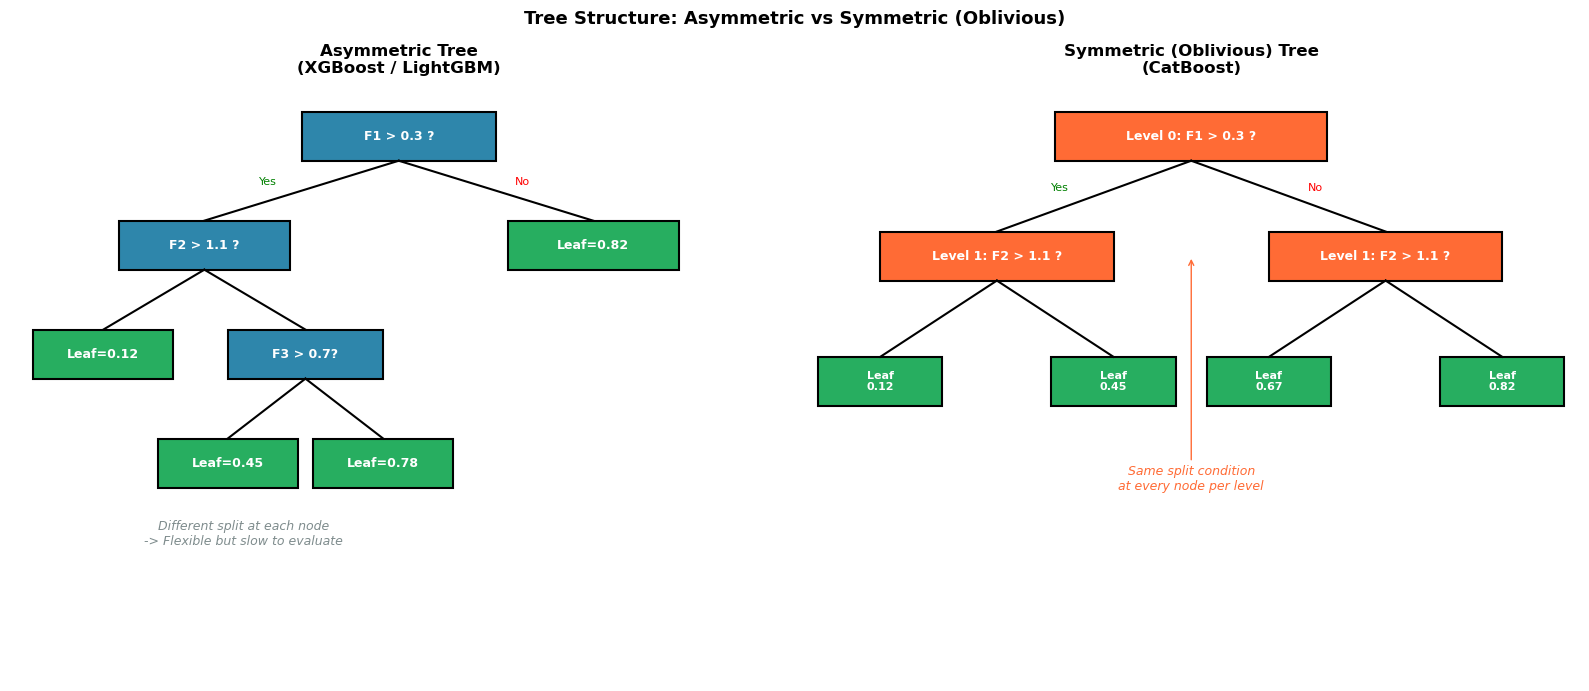

Symmetric trees: same feature+threshold used at each level
  -> Faster prediction (lookup table), less overfitting, but less flexible
  -> CatBoost compensates with many trees and ordered boosting


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def draw_box(ax, x, y, w, h, label, color, fs=8):
    r = plt.Rectangle((x-w/2, y-h/2), w, h,
                       facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(r)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fs, fontweight='bold', color='white')

def draw_line(ax, x1, y1, x2, y2):
    ax.plot([x1, x2], [y1, y2], 'k-', linewidth=1.5)

# --- Asymmetric tree (XGBoost / LightGBM) ---
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 11); ax.axis('off')
ax.set_title('Asymmetric Tree\n(XGBoost / LightGBM)', fontsize=12, fontweight='bold')

draw_box(ax, 5, 10, 2.5, 0.9, 'F1 > 0.3 ?', COLORS['primary'], fs=9)
draw_box(ax, 2.5, 8, 2.2, 0.9, 'F2 > 1.1 ?', COLORS['primary'], fs=9)
draw_box(ax, 7.5, 8, 2.2, 0.9, 'Leaf=0.82', COLORS['success'], fs=9)
draw_line(ax, 5, 9.55, 2.5, 8.45)
draw_line(ax, 5, 9.55, 7.5, 8.45)
ax.text(3.2, 9.1, 'Yes', fontsize=8, color='green')
ax.text(6.5, 9.1, 'No',  fontsize=8, color='red')

draw_box(ax, 1.2, 6, 1.8, 0.9, 'Leaf=0.12', COLORS['success'], fs=9)
draw_box(ax, 3.8, 6, 2.0, 0.9, 'F3 > 0.7?', COLORS['primary'], fs=9)
draw_line(ax, 2.5, 7.55, 1.2, 6.45)
draw_line(ax, 2.5, 7.55, 3.8, 6.45)

draw_box(ax, 2.8, 4, 1.8, 0.9, 'Leaf=0.45', COLORS['success'], fs=9)
draw_box(ax, 4.8, 4, 1.8, 0.9, 'Leaf=0.78', COLORS['success'], fs=9)
draw_line(ax, 3.8, 5.55, 2.8, 4.45)
draw_line(ax, 3.8, 5.55, 4.8, 4.45)

ax.text(3, 2.5, 'Different split at each node\n-> Flexible but slow to evaluate',
        ha='center', fontsize=9, style='italic', color=COLORS['neutral'])

# --- Symmetric tree (CatBoost) ---
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 11); ax.axis('off')
ax.set_title('Symmetric (Oblivious) Tree\n(CatBoost)', fontsize=12, fontweight='bold')

# Depth 0 — same split everywhere at this level
draw_box(ax, 5, 10, 3.5, 0.9, 'Level 0: F1 > 0.3 ?', COLORS['catboost'], fs=9)
# Depth 1 — SAME split condition at both nodes
draw_box(ax, 2.5, 7.8, 3.0, 0.9, 'Level 1: F2 > 1.1 ?', COLORS['catboost'], fs=9)
draw_box(ax, 7.5, 7.8, 3.0, 0.9, 'Level 1: F2 > 1.1 ?', COLORS['catboost'], fs=9)
draw_line(ax, 5, 9.55, 2.5, 8.25)
draw_line(ax, 5, 9.55, 7.5, 8.25)
ax.text(3.2, 9.0, 'Yes', fontsize=8, color='green')
ax.text(6.5, 9.0, 'No',  fontsize=8, color='red')

# Depth 2 — SAME split at all 4 nodes
leaf_colors = [COLORS['success']]*4
leaf_labels = ['Leaf\n0.12','Leaf\n0.45','Leaf\n0.67','Leaf\n0.82']
for i, (lx, ll) in enumerate(zip([1,4,6,9], leaf_labels)):
    draw_box(ax, lx, 5.5, 1.6, 0.9, ll, leaf_colors[i], fs=8)
draw_line(ax, 2.5, 7.35, 1,   5.95)
draw_line(ax, 2.5, 7.35, 4,   5.95)
draw_line(ax, 7.5, 7.35, 6,   5.95)
draw_line(ax, 7.5, 7.35, 9,   5.95)

ax.annotate('Same split condition\nat every node per level',
            xy=(5, 7.8), xytext=(5, 3.5),
            ha='center', fontsize=9, style='italic',
            color=COLORS['catboost'],
            arrowprops=dict(arrowstyle='->', color=COLORS['catboost']))

plt.suptitle('Tree Structure: Asymmetric vs Symmetric (Oblivious)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Symmetric trees: same feature+threshold used at each level')
print('  -> Faster prediction (lookup table), less overfitting, but less flexible')
print('  -> CatBoost compensates with many trees and ordered boosting')

## 3. Classification — Out-of-Box Strength

In [3]:
np.random.seed(42)
X, y = make_classification(
    n_samples=700, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=2, class_sep=1.0, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# CatBoost with DEFAULT parameters — no tuning needed
cb_clf = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0
)
cb_clf.fit(X_train, y_train)

y_pred = cb_clf.predict(X_test)
y_prob = cb_clf.predict_proba(X_test)[:, 1]

print('=== CatBoost Classifier (default-ish params) ===')
print(f'iterations     : {cb_clf.tree_count_}')
print(f'learning_rate  : {cb_clf.learning_rate_}')
print(f'depth          : {cb_clf.get_param("depth")}')
print(f'Test Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}')
print(f'Test F1 Score  : {f1_score(y_test, y_pred):.4f}')
print()
print('CatBoost often achieves strong results with minimal hyperparameter tuning.')

=== CatBoost Classifier (default-ish params) ===
iterations     : 200
learning_rate  : 0.10000000149011612
depth          : 6
Test Accuracy  : 0.9357
Test ROC-AUC   : 0.9679
Test F1 Score  : 0.9343

CatBoost often achieves strong results with minimal hyperparameter tuning.


## 4. Decision Boundary Visualization

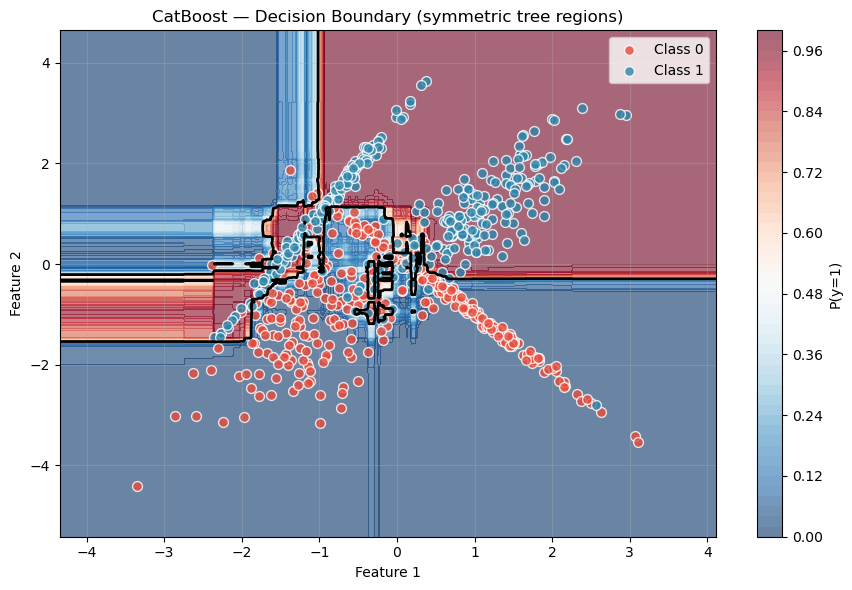

In [4]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = cb_clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y==0, 0], X[y==0, 1], color=COLORS['danger'],
            edgecolors='white', s=50, alpha=0.8, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color=COLORS['primary'],
            edgecolors='white', s=50, alpha=0.8, label='Class 1')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('CatBoost — Decision Boundary (symmetric tree regions)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Native Categorical Handling — CatBoost vs Manual Encoding

In [5]:
np.random.seed(55)
n_cat = 900

# Numeric features
Age      = np.random.randint(18, 70, n_cat).astype(float)
Income   = np.random.uniform(15000, 130000, n_cat)
Balance  = np.random.uniform(0, 50000, n_cat)
Score    = np.random.uniform(300, 850, n_cat)

# Categorical features (as strings — CatBoost handles these directly)
Country  = np.random.choice(['France','Germany','Spain','Italy','Poland'], n_cat)
Product  = np.random.choice(['Savings','Loan','Credit','Mortgage','Investment'], n_cat)
Segment  = np.random.choice(['Retail','SME','Corporate','Private'], n_cat)

feat_names_cat = ['Age','Income','Balance','Score','Country','Product','Segment']
cat_feature_indices = [4, 5, 6]   # indices of categorical columns

# Build as a DataFrame (CatBoost works well with DataFrames)
df_cat = pd.DataFrame({
    'Age':     Age,    'Income':  Income,
    'Balance': Balance,'Score':   Score,
    'Country': Country,'Product': Product,
    'Segment': Segment
})

log_odds = (-2 + 0.02*Age + 0.00001*Income + 0.005*Score
            + 0.5*(Country=='Germany').astype(float)
            - 0.4*(Product=='Loan').astype(float)
            + 0.3*(Segment=='Private').astype(float))
y_cat = (1/(1+np.exp(-log_odds)) > np.random.uniform(0, 1, n_cat)).astype(int)

print(f'Class balance : {np.bincount(y_cat)}  (0=No Churn, 1=Churn)')

X_df_tr, X_df_te, y_cat_tr, y_cat_te = train_test_split(
    df_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

# --- CatBoost: pass raw strings, specify cat_features ---
cb_cat = CatBoostClassifier(
    iterations=200, learning_rate=0.1, depth=6,
    cat_features=['Country','Product','Segment'],
    random_seed=42, verbose=0
)
cb_cat.fit(X_df_tr, y_cat_tr)

# --- XGBoost: requires manual label encoding ---
df_enc = df_cat.copy()
for col in ['Country','Product','Segment']:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])

X_enc_tr, X_enc_te, _, _ = train_test_split(
    df_enc, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)
xgb_cat = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_cat.fit(X_enc_tr, y_cat_tr)

cb_pred  = cb_cat.predict(X_df_te)
cb_prob  = cb_cat.predict_proba(X_df_te)[:,1]
xgb_pred = xgb_cat.predict(X_enc_te)
xgb_prob = xgb_cat.predict_proba(X_enc_te)[:,1]

print(f'\nCatBoost (raw strings, no encoding):')
print(f'  Accuracy={accuracy_score(y_cat_te,cb_pred):.4f}  AUC={roc_auc_score(y_cat_te,cb_prob):.4f}')
print(f'\nXGBoost  (label-encoded manually):')
print(f'  Accuracy={accuracy_score(y_cat_te,xgb_pred):.4f}  AUC={roc_auc_score(y_cat_te,xgb_prob):.4f}')
print()
print('CatBoost uses ordered target statistics instead of label encoding,')
print('which avoids target leakage and often gives better accuracy.')

Class balance : [ 93 807]  (0=No Churn, 1=Churn)

CatBoost (raw strings, no encoding):
  Accuracy=0.8778  AUC=0.7159

XGBoost  (label-encoded manually):
  Accuracy=0.8778  AUC=0.7130

CatBoost uses ordered target statistics instead of label encoding,
which avoids target leakage and often gives better accuracy.


## 6. Early Stopping

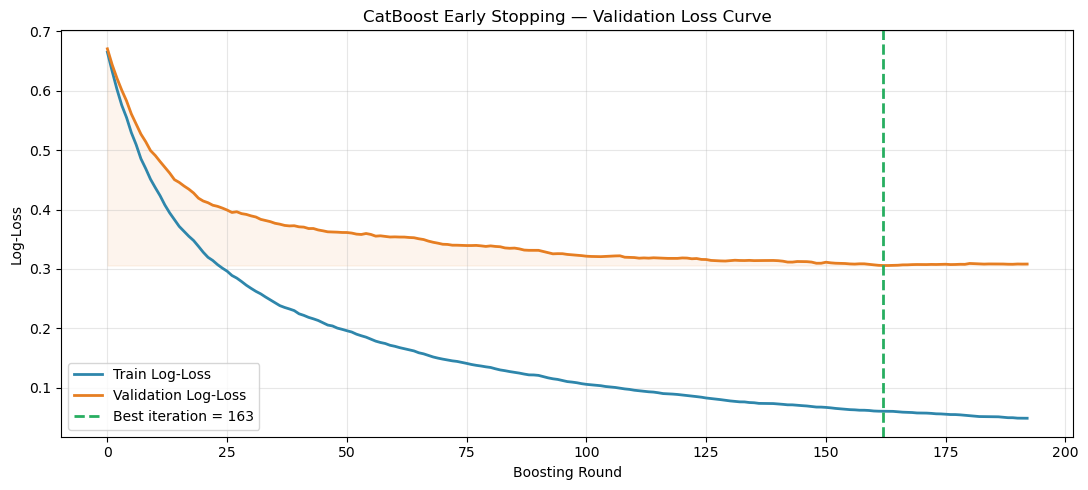

Best iteration : 163
Test Accuracy  : 0.8833
Test ROC-AUC   : 0.9553


In [6]:
np.random.seed(10)
X_es, y_es = make_classification(
    n_samples=900, n_features=20, n_informative=12,
    n_redundant=5, random_state=10
)
X_es_tr, X_es_te, y_es_tr, y_es_te = train_test_split(
    X_es, y_es, test_size=0.2, random_state=42, stratify=y_es
)
X_es_tr2, X_es_val, y_es_tr2, y_es_val = train_test_split(
    X_es_tr, y_es_tr, test_size=0.2, random_state=42, stratify=y_es_tr
)

cb_es = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    early_stopping_rounds=30,
    random_seed=42,
    verbose=0
)
cb_es.fit(
    X_es_tr2, y_es_tr2,
    eval_set=(X_es_val, y_es_val)
)

best_iter  = cb_es.tree_count_
evals_res  = cb_es.get_evals_result()
train_loss = evals_res['learn']['Logloss']
val_loss   = evals_res['validation']['Logloss']

plt.figure(figsize=(11, 5))
plt.plot(train_loss, color=COLORS['primary'],   linewidth=2, label='Train Log-Loss')
plt.plot(val_loss,   color=COLORS['secondary'], linewidth=2, label='Validation Log-Loss')
plt.axvline(best_iter-1, color=COLORS['success'], linestyle='--',
            linewidth=2, label=f'Best iteration = {best_iter}')
plt.fill_between(range(len(val_loss)), val_loss, min(val_loss),
                 alpha=0.08, color=COLORS['secondary'])
plt.xlabel('Boosting Round')
plt.ylabel('Log-Loss')
plt.title('CatBoost Early Stopping — Validation Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

test_acc = accuracy_score(y_es_te, cb_es.predict(X_es_te))
test_auc = roc_auc_score(y_es_te, cb_es.predict_proba(X_es_te)[:,1])
print(f'Best iteration : {best_iter}')
print(f'Test Accuracy  : {test_acc:.4f}')
print(f'Test ROC-AUC   : {test_auc:.4f}')

## 7. Feature Importance — PredictionValuesChange & LossFunctionChange

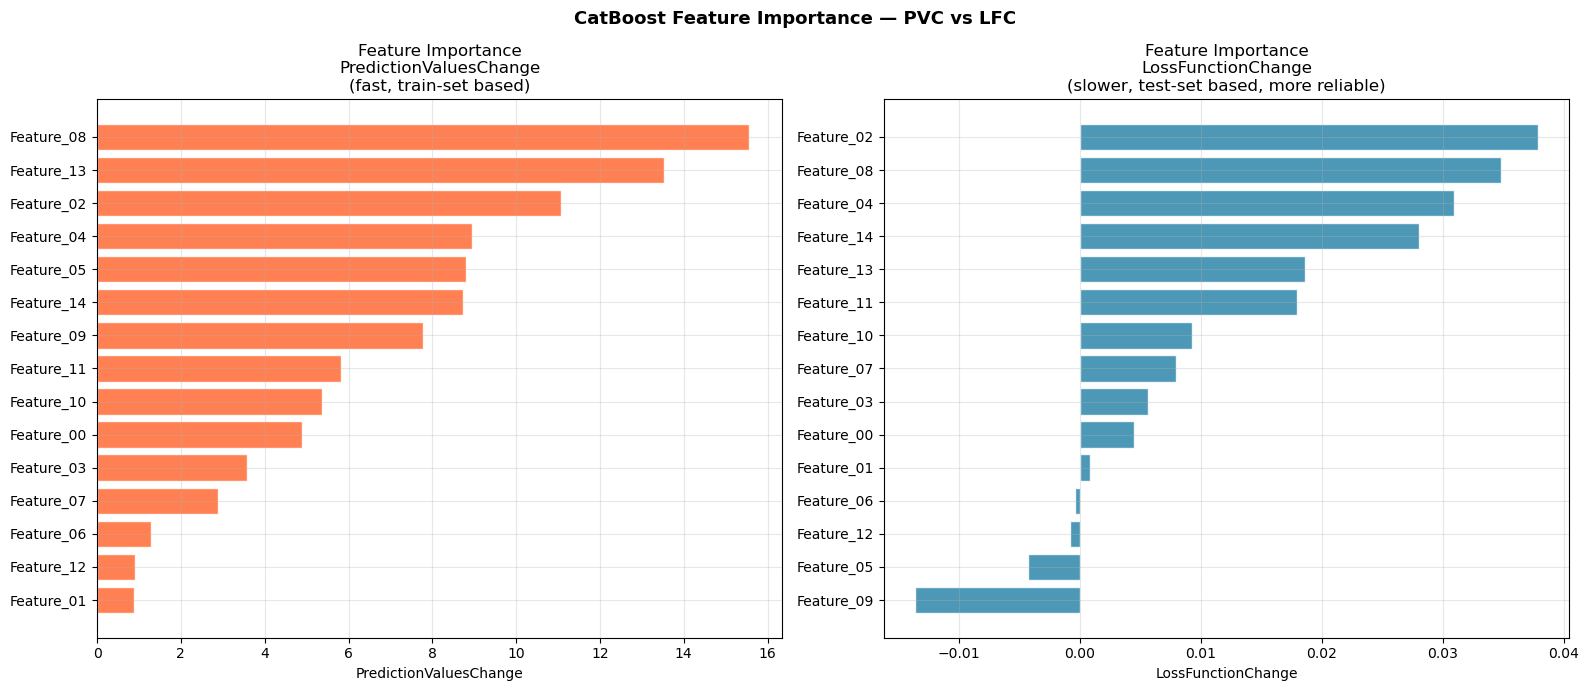

Test Accuracy : 0.9000
Test ROC-AUC  : 0.9712

PredictionValuesChange: avg change in prediction when feature is permuted
LossFunctionChange    : avg change in loss when feature removed (more robust)


In [8]:
np.random.seed(7)
X_imp, y_imp = make_classification(
    n_samples=800, n_features=15, n_informative=8,
    n_redundant=4, random_state=7
)
feat_names_imp = [f'Feature_{i:02d}' for i in range(15)]

X_imp_tr, X_imp_te, y_imp_tr, y_imp_te = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42, stratify=y_imp
)

# Use Pool to attach feature names — correct way in CatBoost
pool_tr = Pool(X_imp_tr, y_imp_tr, feature_names=feat_names_imp)
pool_te = Pool(X_imp_te, y_imp_te, feature_names=feat_names_imp)

cb_imp = CatBoostClassifier(
    iterations=200, learning_rate=0.05, depth=6,
    random_seed=42, verbose=0
)
cb_imp.fit(pool_tr)   # fit on Pool, not raw arrays

imp_pvc = cb_imp.get_feature_importance(type='PredictionValuesChange')
imp_lfc = cb_imp.get_feature_importance(data=pool_te, type='LossFunctionChange')

imp_df = pd.DataFrame({
    'Feature': feat_names_imp,
    'PVC':     imp_pvc,
    'LFC':     imp_lfc
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pvc_s = imp_df.sort_values('PVC', ascending=True)
axes[0].barh(pvc_s['Feature'], pvc_s['PVC'],
             color=COLORS['catboost'], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('PredictionValuesChange')
axes[0].set_title('Feature Importance\nPredictionValuesChange\n(fast, train-set based)')

lfc_s = imp_df.sort_values('LFC', ascending=True)
axes[1].barh(lfc_s['Feature'], lfc_s['LFC'],
             color=COLORS['primary'], edgecolor='white', alpha=0.85)
axes[1].set_xlabel('LossFunctionChange')
axes[1].set_title('Feature Importance\nLossFunctionChange\n(slower, test-set based, more reliable)')

plt.suptitle('CatBoost Feature Importance — PVC vs LFC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Test Accuracy : {accuracy_score(y_imp_te, cb_imp.predict(X_imp_te)):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_imp_te, cb_imp.predict_proba(X_imp_te)[:,1]):.4f}')
print()
print('PredictionValuesChange: avg change in prediction when feature is permuted')
print('LossFunctionChange    : avg change in loss when feature removed (more robust)')


## 8. Effect of depth

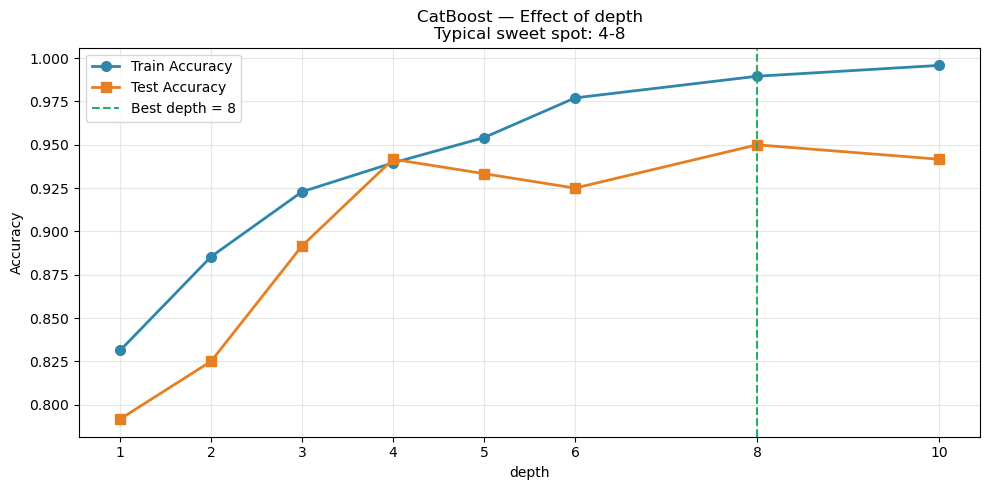

Best depth     : 8
CatBoost depth is bounded by 16 (symmetric tree constraint).
Default depth=6 works well for most datasets.


In [9]:
np.random.seed(42)
X_d, y_d = make_classification(
    n_samples=600, n_features=10, n_informative=6,
    n_redundant=2, random_state=42
)
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d
)

depths     = [1, 2, 3, 4, 5, 6, 8, 10]
tr_accs_d  = []
te_accs_d  = []

for d in depths:
    clf = CatBoostClassifier(
        iterations=100, learning_rate=0.1,
        depth=d, random_seed=42, verbose=0
    )
    clf.fit(X_d_tr, y_d_tr)
    tr_accs_d.append(accuracy_score(y_d_tr, clf.predict(X_d_tr)))
    te_accs_d.append(accuracy_score(y_d_te, clf.predict(X_d_te)))

best_depth = depths[np.argmax(te_accs_d)]

plt.figure(figsize=(10, 5))
plt.plot(depths, tr_accs_d, 'o-', color=COLORS['primary'],
         linewidth=2, markersize=7, label='Train Accuracy')
plt.plot(depths, te_accs_d, 's-', color=COLORS['secondary'],
         linewidth=2, markersize=7, label='Test Accuracy')
plt.axvline(best_depth, color=COLORS['success'], linestyle='--',
            linewidth=1.5, label=f'Best depth = {best_depth}')
plt.xlabel('depth')
plt.ylabel('Accuracy')
plt.title('CatBoost — Effect of depth\nTypical sweet spot: 4-8')
plt.xticks(depths)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best depth     : {best_depth}')
print('CatBoost depth is bounded by 16 (symmetric tree constraint).')
print('Default depth=6 works well for most datasets.')

## 9. CatBoost Regressor

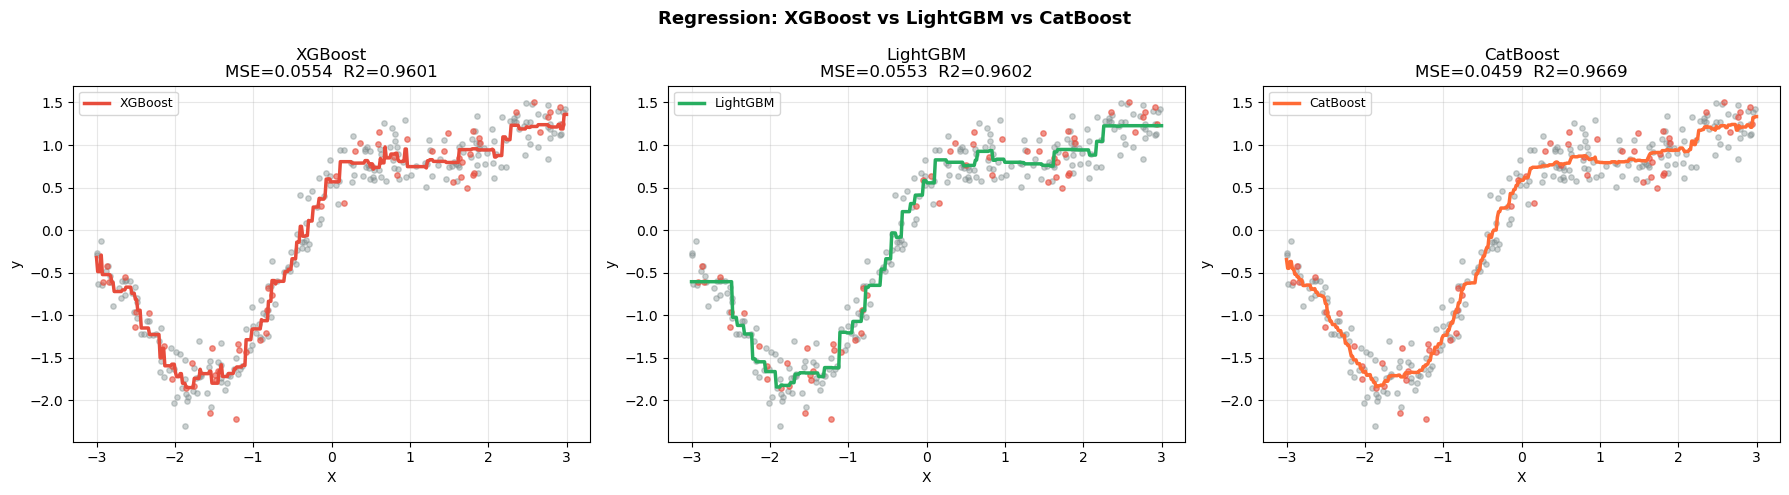

In [10]:
np.random.seed(5)
X_r = np.sort(np.random.uniform(-3, 3, 300)).reshape(-1, 1)
y_r = (np.sin(X_r).ravel() + 0.5*np.cos(2*X_r).ravel()
       + 0.2*X_r.ravel() + np.random.randn(300)*0.2)

X_r_tr, X_r_te, y_r_tr, y_r_te = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)
X_plot = np.linspace(-3, 3, 400).reshape(-1, 1)

from sklearn.ensemble import GradientBoostingRegressor

reg_models = {
    'XGBoost':   XGBRegressor(n_estimators=200, learning_rate=0.05,
                               max_depth=3, eval_metric='rmse',
                               random_state=42, n_jobs=-1),
    'LightGBM':  LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                num_leaves=31, random_state=42,
                                n_jobs=-1, verbose=-1),
    'CatBoost':  CatBoostRegressor(iterations=200, learning_rate=0.05,
                                    depth=6, random_seed=42, verbose=0),
}
plot_colors = [COLORS['xgb'], COLORS['lgbm'], COLORS['catboost']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model), color in zip(axes, reg_models.items(), plot_colors):
    model.fit(X_r_tr, y_r_tr)
    mse = mean_squared_error(y_r_te, model.predict(X_r_te))
    r2  = r2_score(y_r_te,           model.predict(X_r_te))
    ax.scatter(X_r_tr, y_r_tr, s=15, alpha=0.4, color=COLORS['neutral'])
    ax.scatter(X_r_te, y_r_te, s=15, alpha=0.6, color=COLORS['danger'])
    ax.plot(X_plot, model.predict(X_plot), color=color, linewidth=2.5, label=name)
    ax.set_title(f'{name}\nMSE={mse:.4f}  R2={r2:.4f}')
    ax.set_xlabel('X'); ax.set_ylabel('y')
    ax.legend(fontsize=9)

plt.suptitle('Regression: XGBoost vs LightGBM vs CatBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning with GridSearchCV

Best Parameters : {'depth': 8, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.05}
Best CV AUC     : 0.9794
Test Accuracy   : 0.9062
Test ROC-AUC    : 0.9800
Test F1 Score   : 0.9080


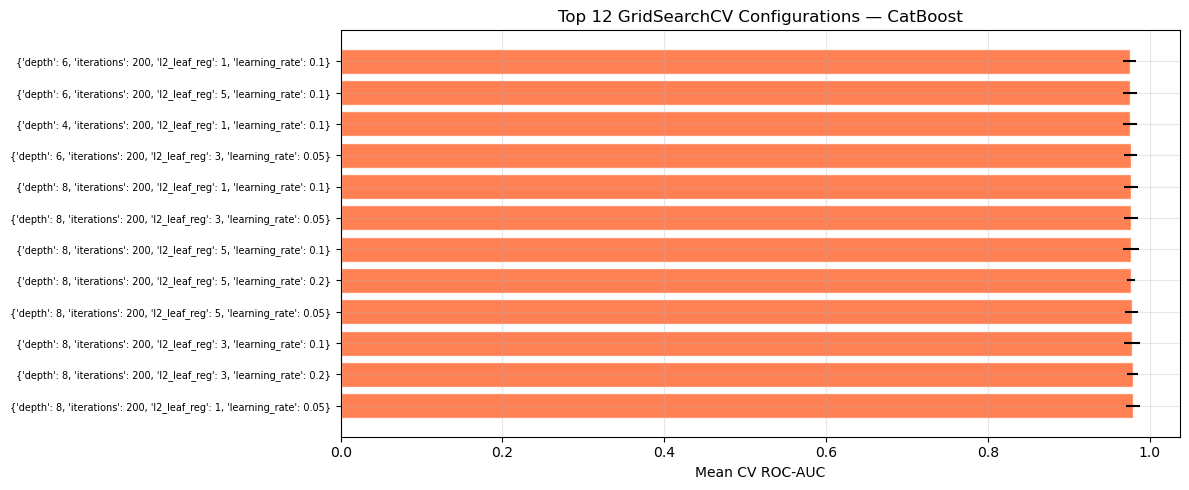

In [11]:
param_grid = {
    'iterations':    [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'depth':         [4, 6, 8],
    'l2_leaf_reg':   [1, 3, 5],
}

cb_base = CatBoostClassifier(random_seed=42, verbose=0)

grid = GridSearchCV(
    cb_base, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_imp_tr, y_imp_tr)

best_cb   = grid.best_estimator_
best_pred = best_cb.predict(X_imp_te)
best_prob = best_cb.predict_proba(X_imp_te)[:, 1]

print(f'Best Parameters : {grid.best_params_}')
print(f'Best CV AUC     : {grid.best_score_:.4f}')
print(f'Test Accuracy   : {accuracy_score(y_imp_te, best_pred):.4f}')
print(f'Test ROC-AUC    : {roc_auc_score(y_imp_te, best_prob):.4f}')
print(f'Test F1 Score   : {f1_score(y_imp_te, best_pred):.4f}')

cv_df = pd.DataFrame(grid.cv_results_)
cv_df = cv_df.sort_values('mean_test_score', ascending=False).head(12)

plt.figure(figsize=(12, 5))
plt.barh(range(len(cv_df)), cv_df['mean_test_score'],
         xerr=cv_df['std_test_score'],
         color=COLORS['catboost'], edgecolor='white', alpha=0.85)
plt.yticks(range(len(cv_df)),
           [str(p) for p in cv_df['params']], fontsize=7)
plt.xlabel('Mean CV ROC-AUC')
plt.title('Top 12 GridSearchCV Configurations — CatBoost')
plt.tight_layout()
plt.show()

## 11. Real-World Offline-Safe Dataset — Insurance Fraud Detection

In [13]:
np.random.seed(42)
X_fraud, y_fraud = make_classification(
    n_samples=1000, n_features=12, n_informative=8,
    n_redundant=3, class_sep=0.9,
    weights=[0.75, 0.25],
    random_state=42
)

feat_names_fraud = ['ClaimAmount','PolicyAge','NumClaims','AgentScore',
                    'VehicleAge','IncidentSeverity','WitnessCount',
                    'DaysToReport','RepairCost','PremiumPaid',
                    'CustomerTenure','RiskScore']

print(f'Dataset shape : {X_fraud.shape}')
print(f'Class balance : {np.bincount(y_fraud)}  (0=Legitimate, 1=Fraud)')

X_fr_tr, X_fr_te, y_fr_tr, y_fr_te = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

# Wrap in Pool — correct way to attach feature names
pool_fr_tr = Pool(X_fr_tr, y_fr_tr, feature_names=feat_names_fraud)
pool_fr_te = Pool(X_fr_te, y_fr_te, feature_names=feat_names_fraud)

cb_fraud = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
cb_fraud.fit(pool_fr_tr, eval_set=pool_fr_te)

fr_pred = cb_fraud.predict(X_fr_te)
fr_prob = cb_fraud.predict_proba(X_fr_te)[:, 1]

print(f'\nTest Accuracy : {accuracy_score(y_fr_te, fr_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_fr_te, fr_prob):.4f}')
print(f'Test F1 Score : {f1_score(y_fr_te, fr_pred):.4f}')
print(f'Test Recall   : {recall_score(y_fr_te, fr_pred):.4f}')

cv_scores = cross_val_score(
    CatBoostClassifier(iterations=200, learning_rate=0.05,
                       depth=6, auto_class_weights='Balanced',
                       random_seed=42, verbose=0),
    X_fraud, y_fraud,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
print(f'5-Fold CV ROC-AUC : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Dataset shape : (1000, 12)
Class balance : [747 253]  (0=Legitimate, 1=Fraud)

Test Accuracy : 0.9250
Test ROC-AUC  : 0.9667
Test F1 Score : 0.8421
Test Recall   : 0.7843
5-Fold CV ROC-AUC : 0.9549 +/- 0.0284


## 12. Full Model Evaluation

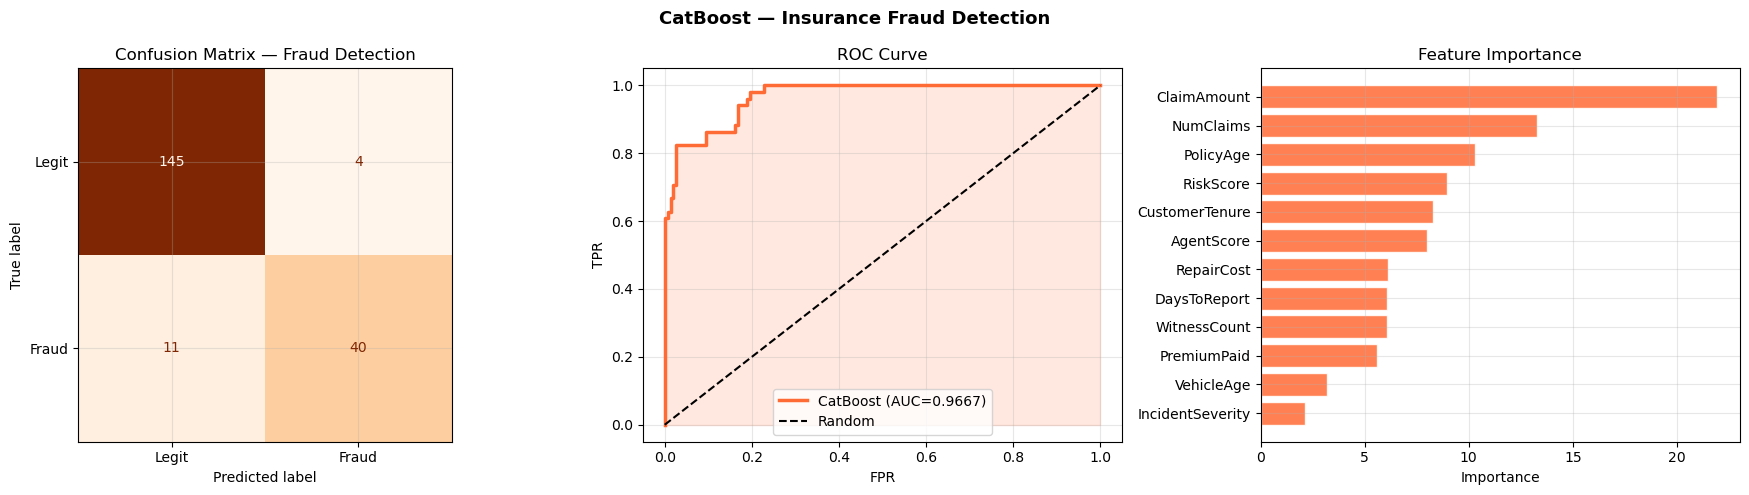

Classification Report:
              precision    recall  f1-score   support

       Legit       0.93      0.97      0.95       149
       Fraud       0.91      0.78      0.84        51

    accuracy                           0.93       200
   macro avg       0.92      0.88      0.90       200
weighted avg       0.92      0.93      0.92       200



In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_fr = confusion_matrix(y_fr_te, fr_pred)
ConfusionMatrixDisplay(cm_fr, display_labels=['Legit','Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges'
)
axes[0].set_title('Confusion Matrix — Fraud Detection')

fpr_f, tpr_f, _ = roc_curve(y_fr_te, fr_prob)
auc_f = roc_auc_score(y_fr_te, fr_prob)
axes[1].plot(fpr_f, tpr_f, color=COLORS['catboost'], linewidth=2.5,
             label=f'CatBoost (AUC={auc_f:.4f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1.5, label='Random')
axes[1].fill_between(fpr_f, tpr_f, alpha=0.15, color=COLORS['catboost'])
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve')
axes[1].legend()

imp_fr = cb_fraud.get_feature_importance(type='PredictionValuesChange')
imp_fr_s = pd.Series(imp_fr, index=feat_names_fraud).sort_values(ascending=True)
axes[2].barh(imp_fr_s.index, imp_fr_s.values,
             color=COLORS['catboost'], edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Importance')
axes[2].set_title('Feature Importance')

plt.suptitle('CatBoost — Insurance Fraud Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_fr_te, fr_pred, target_names=['Legit','Fraud']))

## 13. XGBoost vs LightGBM vs CatBoost — Ultimate Comparison

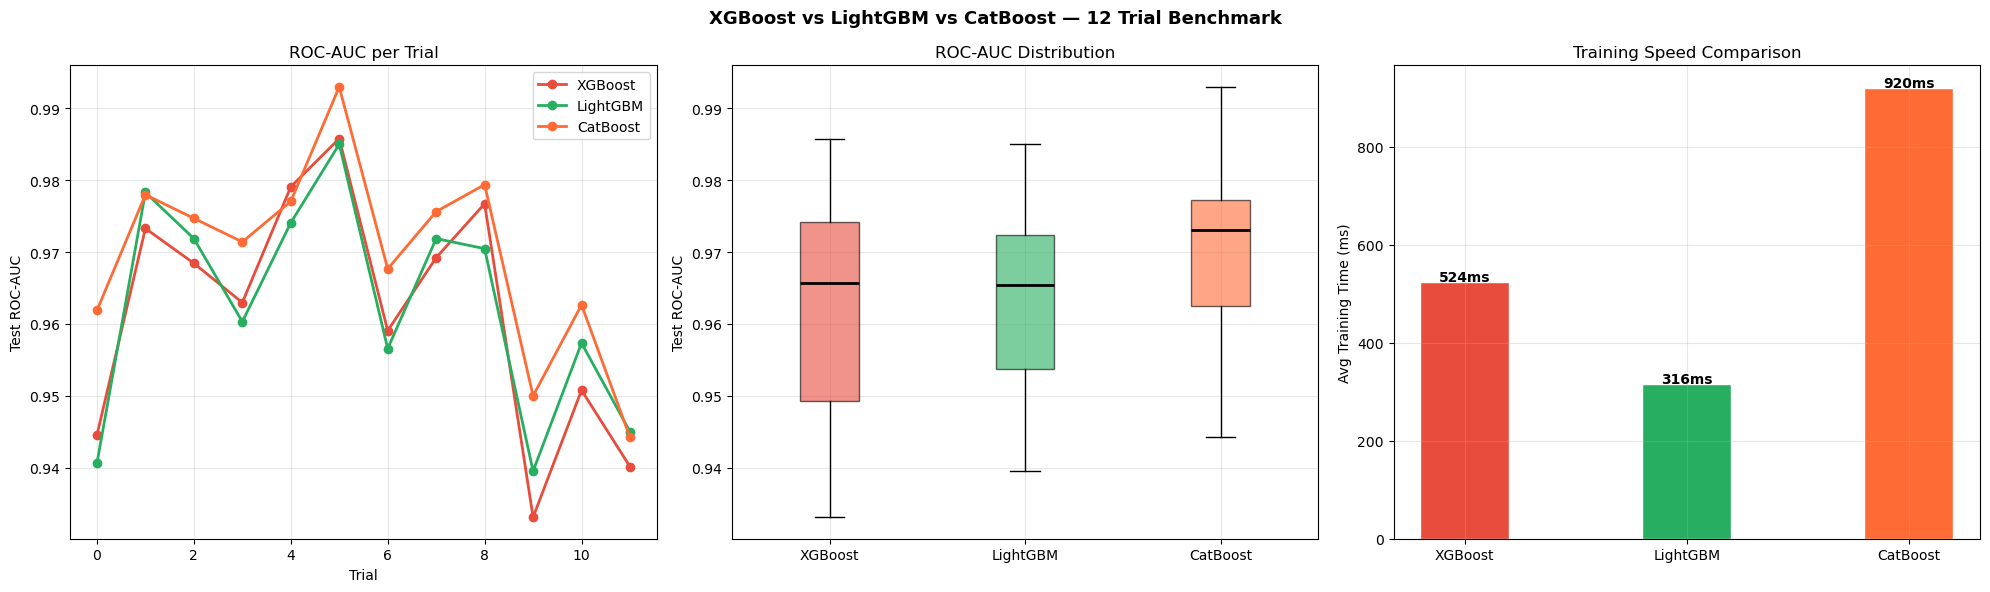

Model          Mean AUC      Std   Avg Time (ms)
------------------------------------------------
XGBoost          0.9619   0.0159           524.2
LightGBM         0.9626   0.0145           316.2
CatBoost         0.9696   0.0128           920.3


In [15]:
n_trials = 12
results  = {'XGBoost': [], 'LightGBM': [], 'CatBoost': []}
times    = {'XGBoost': [], 'LightGBM': [], 'CatBoost': []}

for seed in range(n_trials):
    X_t, y_t = make_classification(
        n_samples=800, n_features=20, n_informative=12,
        n_redundant=5, random_state=seed
    )
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_t, y_t, test_size=0.2, random_state=seed, stratify=y_t
    )
    models_cmp = {
        'XGBoost':  XGBClassifier(n_estimators=200, learning_rate=0.05,
                                   max_depth=6, subsample=0.8,
                                   colsample_bytree=0.8,
                                   eval_metric='logloss',
                                   random_state=seed, n_jobs=-1),
        'LightGBM': LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                    num_leaves=31, subsample=0.8,
                                    colsample_bytree=0.8,
                                    random_state=seed, n_jobs=-1, verbose=-1),
        'CatBoost': CatBoostClassifier(iterations=200, learning_rate=0.05,
                                        depth=6, random_seed=seed, verbose=0),
    }
    for name, model in models_cmp.items():
        t0 = time.time()
        model.fit(X_tr, y_tr)
        t1 = time.time()
        results[name].append(roc_auc_score(y_te, model.predict_proba(X_te)[:,1]))
        times[name].append(t1 - t0)

names  = ['XGBoost','LightGBM','CatBoost']
colors = [COLORS['xgb'], COLORS['lgbm'], COLORS['catboost']]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# AUC line
for name, color in zip(names, colors):
    axes[0].plot(results[name], 'o-', color=color,
                 linewidth=2, markersize=6, label=name)
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Test ROC-AUC')
axes[0].set_title('ROC-AUC per Trial')
axes[0].legend()

# Boxplot
bp = axes[1].boxplot([results[n] for n in names], labels=names,
                     patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_ylabel('Test ROC-AUC')
axes[1].set_title('ROC-AUC Distribution')

# Speed
mean_times = [np.mean(times[n])*1000 for n in names]
bars = axes[2].bar(names, mean_times, color=colors, edgecolor='white', width=0.4)
axes[2].set_ylabel('Avg Training Time (ms)')
axes[2].set_title('Training Speed Comparison')
for bar, t in zip(bars, mean_times):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+2, f'{t:.0f}ms',
                 ha='center', fontweight='bold')

plt.suptitle('XGBoost vs LightGBM vs CatBoost — 12 Trial Benchmark',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'{'Model':<12} {'Mean AUC':>10} {'Std':>8} {'Avg Time (ms)':>15}')
print('-' * 48)
for name in names:
    m = np.mean(results[name])
    s = np.std(results[name])
    t = np.mean(times[name])*1000
    print(f'{name:<12} {m:>10.4f} {s:>8.4f} {t:>15.1f}')

## 14. Final Summary & Key Takeaways

In [ ]:
print('=' * 70)
print('               CATBOOST - KEY TAKEAWAYS')
print('=' * 70)

takeaways = [
    ('Core idea',          'Ordered boosting + ordered target stats for categoricals'),
    ('Categoricals',       'Pass raw strings with cat_features — no encoding needed'),
    ('Ordered stats',      'Encodes categoricals without target leakage'),
    ('Symmetric trees',    'Same split at every node per level -> fast inference'),
    ('depth',              'Controls symmetric tree depth; default=6 works well'),
    ('l2_leaf_reg',        'L2 regularization on leaf values; increase to reduce overfit'),
    ('Early stopping',     'Use eval_set + early_stopping_rounds in fit()'),
    ('Class imbalance',    'auto_class_weights="Balanced" handles it natively'),
    ('Feature importance', 'PredictionValuesChange (fast) or LossFunctionChange (reliable)'),
    ('Out-of-box',         'Strong default params — often needs less tuning than XGB/LGBM'),
    ('Missing values',     'Handled natively — no imputation needed'),
    ('Feature scaling',    'NOT required — tree-based splits'),
    ('vs LightGBM',        'Slower but better categoricals; LightGBM faster on large data'),
    ('Best use case',      'Datasets with many categorical features and limited time to tune'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<22}  ->  {detail}')

print()
print('Boosting Trilogy Summary:')
print('  XGBoost   -> Robust, widely supported, great baseline')
print('  LightGBM  -> Fastest on large data, great with histogram splits')
print('  CatBoost  -> Best native categoricals, strong out-of-box, ordered boosting')
print('=' * 70)

---
## Practice Exercises

1. **Add more string categorical features** and compare CatBoost vs manually one-hot encoded XGBoost.
2. **Tune bagging_temperature** — how does it compare with subsample in XGBoost/LightGBM?
3. **Use Pool API** — wrap data in `catboost.Pool` with column names and categorical indices.
4. **Compare ordered vs plain boosting** — set `boosting_type='Plain'` and compare with default `'Ordered'`.
5. **Plot SHAP values** — CatBoost has built-in SHAP support via `get_feature_importance(type='ShapValues')`.
6. **Run all three on a real Kaggle dataset** — download any tabular competition dataset and benchmark XGBoost, LightGBM, and CatBoost head-to-head.

---
*Notebook created for the ML Repository — CatBoost module.*